In [1]:
# Step 1 — Preprocess & Split (modified for new fine-tune plan)
import os, random, numpy as np
import tensorflow as tf
import cv2
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support,
                             cohen_kappa_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Mount Google Drive
drive.mount('/content/drive')

# Paths
dataset_root = '/content/drive/MyDrive/PlantDoc-Dataset'
train_dir = f'{dataset_root}/train'
test_dir  = f'{dataset_root}/test'

# Loader
def load_plantdoc_data(data_dir, img_size=(299, 299)):
    X, y = [], []
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}
    for cls_name in class_names:
        cls_dir = os.path.join(data_dir, cls_name)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            X.append(img)
            y.append(class_to_idx[cls_name])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), class_names

# Load train/test
X_train, y_train, class_names = load_plantdoc_data(train_dir)
X_test,  y_test,  _           = load_plantdoc_data(test_dir)
num_classes = len(class_names)

# Normalize
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Split train → 80% train + 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# 🔹 NOTE for fine-tuning:
# - Later we will unfreeze *specific layers/blocks* of Xception (region-based training).
# - A callback will dynamically set `layer.trainable=True` after certain validation accuracy/epochs.
# - Post-training quantization (FP32/INT8) will be applied only on test dataset (Step 10).


Mounted at /content/drive
Train: (1852, 299, 299, 3), Val: (464, 299, 299, 3), Test: (236, 299, 299, 3)


In [2]:
# Step 2 — Class Weights (handle imbalance, unchanged logic but aligned with fine-tune plan)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights)

# 🔹 NOTE for fine-tuning:
# - These class weights will be applied during training.
# - Validation monitoring will be based on `val_accuracy` in later steps.


Class Weights: {0: np.float64(1.1063321385902032), 1: np.float64(1.0392817059483725), 2: np.float64(1.0887713109935333), 3: np.float64(1.6331569664902998), 4: np.float64(1.3718518518518519), 5: np.float64(0.8165784832451499), 6: np.float64(1.8050682261208577), 7: np.float64(1.3449527959331882), 8: np.float64(0.4763374485596708), 9: np.float64(0.8069716775599128), 10: np.float64(0.8364950316169828), 11: np.float64(0.7884206045125586), 12: np.float64(0.879392212725546), 13: np.float64(0.7884206045125586), 14: np.float64(1.4911433172302737), 15: np.float64(0.6999244142101285), 16: np.float64(0.9798941798941799), 17: np.float64(1.162586315128688), 18: np.float64(0.6292898402990146), 19: np.float64(1.595176571920758), 20: np.float64(0.879392212725546), 21: np.float64(0.846822130772748), 22: np.float64(1.9597883597883599), 23: np.float64(1.247138047138047), 24: np.float64(1.008714596949891), 25: np.float64(1.4911433172302737), 26: np.float64(1.5242798353909466)}


In [3]:
# Step 3 — Validation Monitoring (Kappa + Val Accuracy)
class KappaCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val_cat):
        super().__init__()
        self.X_val = X_val
        self.y_val_cat = y_val_cat

    def on_epoch_end(self, epoch, logs=None):
        # predictions
        y_val_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        y_val_true = np.argmax(self.y_val_cat, axis=1)

        # compute kappa
        kappa = cohen_kappa_score(y_val_true, y_val_pred)

        # log both val_accuracy and kappa
        val_acc = logs.get("val_accuracy")
        print(f"\nEpoch {epoch+1} — Val Accuracy: {val_acc:.4f} — Val Cohen’s Kappa: {kappa:.4f}")


In [4]:
# Step 4 — Build Model (with augmentation & region-based fine-tuning)
def build_xception(num_classes, input_shape=(299, 299, 3), dropout=0.4, lr=1e-3,
                   label_smoothing=0.05, trainable_layers=0, trainable_region=None):
    """
    Args:
        num_classes: number of classes
        input_shape: input image shape
        dropout: dropout rate
        lr: learning rate
        label_smoothing: label smoothing factor
        trainable_layers: unfreeze last N layers (default)
        trainable_region: tuple (start_idx, end_idx) to unfreeze a region of base model
    """

    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name="augment")

    base = Xception(include_top=False, weights='imagenet', input_shape=input_shape)

    # Freeze everything first
    for layer in base.layers:
        layer.trainable = False

    # Option 1: Unfreeze last N layers
    if trainable_layers > 0:
        for layer in base.layers[-trainable_layers:]:
            layer.trainable = True

    # Option 2: Unfreeze specific region [start:end]
    if trainable_region is not None:
        start, end = trainable_region
        for layer in base.layers[start:end]:
            layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = aug(inputs)
    x = base(x, training=False)   # base is partly frozen/unfrozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=['accuracy',
                 tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
                 tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model


In [5]:
# Step 5 — Warmup (train head, base frozen, monitoring val_accuracy)
warmup_epochs = 3
model = build_xception(
    num_classes=num_classes,
    lr=1e-3,
    dropout=0.4,
    label_smoothing=0.05,
    trainable_layers=0  # base frozen during warmup
)
model.summary()

chkpt_path = "/content/best_warmup.keras"
callbacks_warmup = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', patience=2, factor=0.3, min_lr=1e-7, mode='max'),
    ModelCheckpoint(chkpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    KappaCallback(X_val, y_val_cat)
]

history_warmup = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=warmup_epochs,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks_warmup,
    verbose=1
)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,926,467 (83.64 MB)

 Trainable params: 1,063,963 (4.06 MB)

 Non-trainable params: 20,862,504 (79.58 MB)

Epoch 1/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.1618 - auc: 0.6898 - loss: 3.5224 - top3_acc: 0.3399 
Epoch 1: val_accuracy improved from -inf to 0.34914, saving model to /content/best_warmup.keras

Epoch 1 — Val Accuracy: 0.3491 — Val Cohen’s Kappa: 0.3211
58/58 ━━━━━━━━━━━━━━━━━━━━ 1190s 21s/step - accuracy: 0.1629 - auc: 0.6912 - loss: 3.5157 - top3_acc: 0.3419 - val_accuracy: 0.3491 - val_auc: 0.9003 - val_loss: 2.3265 - val_top3_acc: 0.6530 - learning_rate: 0.0010
Epoch 2/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.4042 - auc: 0.8859 - loss: 2.2118 - top3_acc: 0.6807 
Epoch 2: val_accuracy improved from 0.34914 to 0.44397, saving model to /content/best_warmup.keras

Epoch 2 — Val Accuracy: 0.4440 — Val Cohen’s Kappa: 0.4219
58/58 ━━━━━━━━━━━━━━━━━━━━ 1233s 21s/step - accuracy: 0.4041 - auc: 0.8860 - loss: 2.2127 - top3_acc: 0.6804 - val_accuracy: 0.4440 - val_auc: 0.9257 - val_loss: 2.0155 - val_top3_acc: 0.7328 - learning_rate: 0.0010
Epoch 3/3
58/58 ━━━

In [ ]:
# Step 6 — Fine-tune (unfreeze last N layers, monitor val_accuracy)
N_UNFREEZE = 60  # specific region: last N layers

# Find base model inside current model
base = None
for lyr in model.layers:
    if isinstance(lyr, tf.keras.Model) and lyr.name.startswith('xception'):
        base = lyr; break
if base is None:
    base = model.layers[2]  # fallback

# Freeze all, unfreeze last N layers (specific region training)
for l in base.layers:
    l.trainable = False
for l in base.layers[-N_UNFREEZE:]:
    l.trainable = True

# Recompile with lower LR
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
             tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

chkpt_path_ft = "/content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras"
callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),  # 🔹 monitor val_accuracy
    ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.3, min_lr=1e-7), # 🔹 monitor val_accuracy
    ModelCheckpoint(chkpt_path_ft, monitor='val_accuracy', save_best_only=True, verbose=1), # 🔹 monitor val_accuracy
    KappaCallback(X_val, y_val_cat)
]

history_ft = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 27s/step - accuracy: 0.4414 - auc: 0.9029 - loss: 2.0369 - top3_acc: 0.7019 
Epoch 1: val_accuracy improved from -inf to 0.51940, saving model to /content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras

Epoch 1 — Val Accuracy: 0.5194 — Val Cohen’s Kappa: 0.5001
58/58 ━━━━━━━━━━━━━━━━━━━━ 2031s 35s/step - accuracy: 0.4418 - auc: 0.9033 - loss: 2.0355 - top3_acc: 0.7024 - val_accuracy: 0.5194 - val_auc: 0.9493 - val_loss: 1.6952 - val_top3_acc: 0.7909 - learning_rate: 1.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.6748 - auc: 0.9594 - loss: 1.3263 - top3_acc: 0.8869 
Epoch 2: val_accuracy improved from 0.51940 to 0.54526, saving model to /content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras

Epoch 2 — Val Accuracy: 0.5453 — Val Cohen’s Kappa: 0.5267
58/58 ━━━━━━━━━━━━━━━━━━━━ 1992s 34s/step - accuracy: 0.6743 - auc: 0.9596 - loss: 1.3272 - top3_acc: 0.8867 - val_accuracy: 0.5453 - val_auc: 0.9553 - val_loss:

In [2]:
from tensorflow import keras

model = keras.models.load_model("/content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras")
print("✅ Loaded best fine-tuned model")


✅ Loaded best fine-tuned model


In [3]:
# Step 7 — Evaluate
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)
y_true = y_test

acc = accuracy_score(y_true, y_pred)
f1w = f1_score(y_true, y_pred, average='weighted')

try:
    macro_auc = roc_auc_score(y_test_cat, y_pred_proba, multi_class='ovr', average='macro')
except ValueError:
    macro_auc = np.nan

kappa = cohen_kappa_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Weighted F1: {f1w:.4f}")
print(f"Test Macro AUC (OvR): {macro_auc:.4f}")
print(f"Test Cohen's Kappa: {kappa:.4f}")
print("Classification Report:\n", report)


Test Accuracy: 0.5763
Test Weighted F1: 0.5862
Test Macro AUC (OvR): 0.9624
Test Cohen's Kappa: 0.5598
Classification Report:
                             precision    recall  f1-score   support

           Apple Scab Leaf       0.75      0.60      0.67        10
                Apple leaf       0.50      1.00      0.67         9
           Apple rust leaf       0.70      0.70      0.70        10
          Bell_pepper leaf       0.50      0.38      0.43         8
     Bell_pepper leaf spot       0.33      0.56      0.42         9
            Blueberry leaf       0.86      0.55      0.67        11
               Cherry leaf       0.78      0.70      0.74        10
       Corn Gray leaf spot       0.10      0.25      0.14         4
          Corn leaf blight       0.62      0.42      0.50        12
            Corn rust leaf       0.89      0.80      0.84        10
                Peach leaf       1.00      0.67      0.80         9
  Potato leaf early blight       0.31      0.62      0.4

In [4]:
# Step 8 — Post-Training Quantization & Evaluation

# 1. Save the trained FP32 model
model.save("xception_final.keras")

# 2. Convert FP32 → INT8 TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # enables INT8 quantization
tflite_model_int8 = converter.convert()

# Save INT8 model
with open("xception_int8.tflite", "wb") as f:
    f.write(tflite_model_int8)

print("INT8 quantized model saved as xception_int8.tflite")

# 3. Run inference on test dataset with INT8 model
interpreter = tf.lite.Interpreter(model_path="xception_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_int8 = []
for i in range(len(X_test)):
    img = np.expand_dims(X_test[i], axis=0).astype(np.float32)  # keep float32 input
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_int8.append(np.argmax(output))

y_pred_int8 = np.array(y_pred_int8)

# 4. Evaluate metrics on INT8 model
acc_int8 = accuracy_score(y_test, y_pred_int8)
f1w_int8 = f1_score(y_test, y_pred_int8, average='weighted')
kappa_int8 = cohen_kappa_score(y_test, y_pred_int8)

print("\n INT8 Quantized Model Evaluation:")
print(f"Test Accuracy (INT8): {acc_int8:.4f}")
print(f"Test Weighted F1 (INT8): {f1w_int8:.4f}")
print(f"Test Cohen's Kappa (INT8): {kappa_int8:.4f}")


Saved artifact at '/tmp/tmpum1_jesn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  137413120494864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120496976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120497744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120496400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120495440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120496784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120497360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120497168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120496592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120498704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137413120498

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



 INT8 Quantized Model Evaluation:
Test Accuracy (INT8): 0.5678
Test Weighted F1 (INT8): 0.5789
Test Cohen's Kappa (INT8): 0.5510


In [5]:

import tensorflow as tf

# 1. Load your trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras")

# 2. Convert to INT8 TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # enables INT8 quantization
tflite_model_int8 = converter.convert()

# 3. Save to Google Drive
save_path = "/content/drive/MyDrive/Xceptionfinetune3/xception_int8.tflite"
with open(save_path, "wb") as f:
    f.write(tflite_model_int8)

print(f"✅ INT8 quantized model saved at: {save_path}")


Saved artifact at '/tmp/tmpg93revvx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  137410230139408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230140560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230140752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230139024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230137872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230139216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230138448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230138256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230140176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230137104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410230137

In [6]:
import tensorflow as tf
import numpy as np
import os

def tflite_model_summary(model_path):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    tensor_details = interpreter.get_tensor_details()
    total_params = 0
    total_bytes = 0

    for d in tensor_details:
        shape = d['shape']
        dtype = np.dtype(d['dtype'])
        num_params = np.prod(shape)
        total_params += num_params
        total_bytes += num_params * dtype.itemsize

    print("\n=== Quantized TFLite Model Summary ===")
    print(f"Total params: {total_params:,}")
    print(f"Model size on disk: {os.path.getsize(model_path)/1024/1024:.2f} MB")
    print(f"In-memory param size: {total_bytes/1024/1024:.2f} MB")
    print("Trainable params: 0 (TFLite models are frozen for inference)")
    print("Non-trainable params: all")
    print("Optimizer params: 0 (not stored in TFLite)")

# Example usage
tflite_model_summary("/content/drive/MyDrive/Xceptionfinetune3/xception_int8.tflite")



=== Quantized TFLite Model Summary ===
Total params: 79,599,384
Model size on disk: 21.55 MB
In-memory param size: 203.17 MB
Trainable params: 0 (TFLite models are frozen for inference)
Non-trainable params: all
Optimizer params: 0 (not stored in TFLite)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
import tensorflow as tf

# Load INT8 quantized model
interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/Xceptionfinetune3/xception_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run inference
y_pred_int8 = []
for i in range(len(X_test)):
    img = np.expand_dims(X_test[i], axis=0).astype(np.float32)  # keep float32 input
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_int8.append(np.argmax(output))

y_pred_int8 = np.array(y_pred_int8)

# Evaluate metrics
acc_int8 = accuracy_score(y_test, y_pred_int8)
f1w_int8 = f1_score(y_test, y_pred_int8, average='weighted')
kappa_int8 = cohen_kappa_score(y_test, y_pred_int8)

print("\n📊 INT8 Quantized Model Evaluation:")
print(f"Test Accuracy: {acc_int8:.4f}")
print(f"Weighted F1: {f1w_int8:.4f}")
print(f"Cohen's Kappa: {kappa_int8:.4f}")



📊 INT8 Quantized Model Evaluation:
Test Accuracy: 0.5678
Weighted F1: 0.5789
Cohen's Kappa: 0.5510


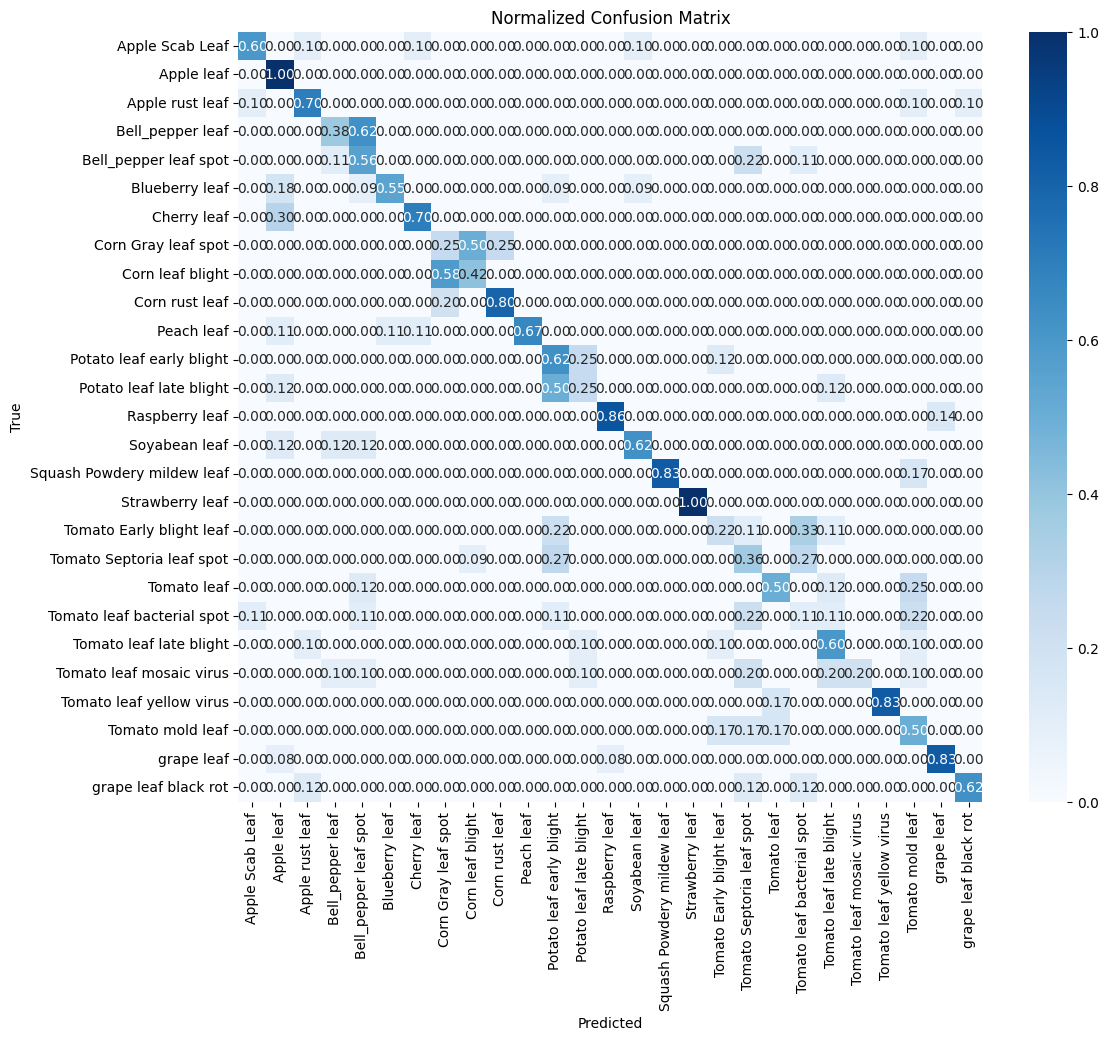

Apple Scab Leaf           | Precision: 0.750, Recall: 0.600, F1: 0.667, Support: 10
Apple leaf                | Precision: 0.500, Recall: 1.000, F1: 0.667, Support: 9
Apple rust leaf           | Precision: 0.700, Recall: 0.700, F1: 0.700, Support: 10
Bell_pepper leaf          | Precision: 0.500, Recall: 0.375, F1: 0.429, Support: 8
Bell_pepper leaf spot     | Precision: 0.333, Recall: 0.556, F1: 0.417, Support: 9
Blueberry leaf            | Precision: 0.857, Recall: 0.545, F1: 0.667, Support: 11
Cherry leaf               | Precision: 0.778, Recall: 0.700, F1: 0.737, Support: 10
Corn Gray leaf spot       | Precision: 0.100, Recall: 0.250, F1: 0.143, Support: 4
Corn leaf blight          | Precision: 0.625, Recall: 0.417, F1: 0.500, Support: 12
Corn rust leaf            | Precision: 0.889, Recall: 0.800, F1: 0.842, Support: 10
Peach leaf                | Precision: 1.000, Recall: 0.667, F1: 0.800, Support: 9
Potato leaf early blight  | Precision: 0.312, Recall: 0.625, F1: 0.417, Support: 

In [8]:
# Step 9 — Confusion Matrix & Per-class PRF

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize per row

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

# Per-class Precision, Recall, F1
prf = precision_recall_fscore_support(y_true, y_pred, labels=np.arange(num_classes))
for i, cls in enumerate(class_names):
    print(f"{cls:25s} | "
          f"Precision: {prf[0][i]:.3f}, "
          f"Recall: {prf[1][i]:.3f}, "
          f"F1: {prf[2][i]:.3f}, "
          f"Support: {prf[3][i]}")


In [9]:
import tensorflow as tf
import os
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

# 1. Load trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras")

# 2. Convert to FP32 TFLite (no quantization)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model_fp32 = converter.convert()

fp32_path = "/content/drive/MyDrive/Xceptionfinetune3/xception_fp32.tflite"
with open(fp32_path, "wb") as f:
    f.write(tflite_model_fp32)

print("✅ FP32 TFLite model saved as:", fp32_path)

# 3. Model size on disk
size_mb = os.path.getsize(fp32_path) / (1024 * 1024)
print(f"📦 FP32 TFLite model size: {size_mb:.2f} MB")

# 4. Evaluate FP32 TFLite model on test set
interpreter = tf.lite.Interpreter(model_path=fp32_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_fp32 = []
for i in range(len(X_test)):
    img = np.expand_dims(X_test[i], axis=0).astype(np.float32)  # input must be float32
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_fp32.append(np.argmax(output))

y_pred_fp32 = np.array(y_pred_fp32)

acc_fp32 = accuracy_score(y_test, y_pred_fp32)
f1w_fp32 = f1_score(y_test, y_pred_fp32, average='weighted')
kappa_fp32 = cohen_kappa_score(y_test, y_pred_fp32)

print("\n📊 FP32 TFLite Model Evaluation:")
print(f"Test Accuracy: {acc_fp32:.4f}")
print(f"Weighted F1: {f1w_fp32:.4f}")
print(f"Cohen's Kappa: {kappa_fp32:.4f}")

# 5. "Summary" equivalent for TFLite (params size only)
num_params = np.sum([np.prod(v.shape) for v in model.weights])
mem_size_mb = num_params * 4 / (1024*1024)  # FP32 = 4 bytes
print(f"\n📝 Approximate Model Summary after FP32 Quantization:")
print(f"Total params: {num_params:,}")
print(f"In-memory size (FP32): {mem_size_mb:.2f} MB")
print(f"Trainable params: 0 (TFLite models are frozen for inference)")
print(f"Non-trainable params: all")
print(f"Optimizer params: 0")


Saved artifact at '/tmp/tmp3_tqsaza'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  137410581322384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581323344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581323152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581322768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581323920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581322000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581323536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581323728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581321232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581324880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410581324

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



📊 FP32 TFLite Model Evaluation:
Test Accuracy: 0.5763
Weighted F1: 0.5862
Cohen's Kappa: 0.5598

📝 Approximate Model Summary after FP32 Quantization:
Total params: 21,926,467
In-memory size (FP32): 83.64 MB
Trainable params: 0 (TFLite models are frozen for inference)
Non-trainable params: all
Optimizer params: 0


In [10]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

# Paths
orig_model_path = "/content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras"
fp32_path = "/content/drive/MyDrive/Xceptionfinetune3/xception_fp32.tflite"

# ✅ Check if file exists and get size
if os.path.exists(orig_model_path):
    orig_size_mb = os.path.getsize(orig_model_path) / (1024 * 1024)
    print(f"📦 Original Keras model size: {orig_size_mb:.2f} MB")
else:
    print("⚠️ Original Keras model not found at:", orig_model_path)

# Load trained model
model = tf.keras.models.load_model(orig_model_path)

# Convert to FP32 TFLite (no quantization)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model_fp32 = converter.convert()

# Save directly to Google Drive
with open(fp32_path, "wb") as f:
    f.write(tflite_model_fp32)

print("✅ FP32 TFLite model saved at:", fp32_path)

# ✅ FP32 TFLite model size
fp32_size_mb = os.path.getsize(fp32_path) / (1024 * 1024)
print(f"📦 FP32 TFLite model size: {fp32_size_mb:.2f} MB")

# Evaluate FP32 TFLite model
interpreter = tf.lite.Interpreter(model_path=fp32_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_fp32 = []
for i in range(len(X_test)):
    img = np.expand_dims(X_test[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_fp32.append(np.argmax(output))

y_pred_fp32 = np.array(y_pred_fp32)

acc_fp32 = accuracy_score(y_test, y_pred_fp32)
f1w_fp32 = f1_score(y_test, y_pred_fp32, average='weighted')
kappa_fp32 = cohen_kappa_score(y_test, y_pred_fp32)

print("\n📊 FP32 TFLite Model Evaluation:")
print(f"Test Accuracy: {acc_fp32:.4f}")
print(f"Weighted F1: {f1w_fp32:.4f}")
print(f"Cohen's Kappa: {kappa_fp32:.4f}")

# Model param summary
num_params = np.sum([np.prod(v.shape) for v in model.weights])
mem_size_mb = num_params * 4 / (1024*1024)
print(f"\n📝 Approximate Model Summary after FP32 Quantization:")
print(f"Total params: {num_params:,}")
print(f"In-memory size (FP32): {mem_size_mb:.2f} MB")
print("Trainable params: 0 (TFLite models are frozen for inference)")
print("Non-trainable params: all")
print("Optimizer params: 0")


📦 Original Keras model size: 197.47 MB
Saved artifact at '/tmp/tmpmiivf901'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  137410567961488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567960336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567960528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567960912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567959760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567961104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567960144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567959952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567961296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137410567958800: TensorSpec(shape=(), dtype

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



📊 FP32 TFLite Model Evaluation:
Test Accuracy: 0.5763
Weighted F1: 0.5862
Cohen's Kappa: 0.5598

📝 Approximate Model Summary after FP32 Quantization:
Total params: 21,926,467
In-memory size (FP32): 83.64 MB
Trainable params: 0 (TFLite models are frozen for inference)
Non-trainable params: all
Optimizer params: 0


In [11]:
import os

# Paths
orig_model_path = "/content/drive/MyDrive/Xceptionfinetune3/best_finetune.keras"
fp32_tflite_path = "/content/drive/MyDrive/Xceptionfinetune3/xception_fp32.tflite"

# Function to print model size
def print_model_size(path, name):
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"📦 {name} size on disk: {size_mb:.2f} MB")
    else:
        print(f"⚠️ {name} not found at {path}")

# Print sizes
print_model_size(orig_model_path, "Original Keras model")
print_model_size(fp32_tflite_path, "FP32 TFLite model")


📦 Original Keras model size on disk: 197.47 MB
📦 FP32 TFLite model size on disk: 83.38 MB
